# 빅데이터 컴퓨팅 2차 프로그래밍 과제
### 20250567 한성규

## PC 캡쳐

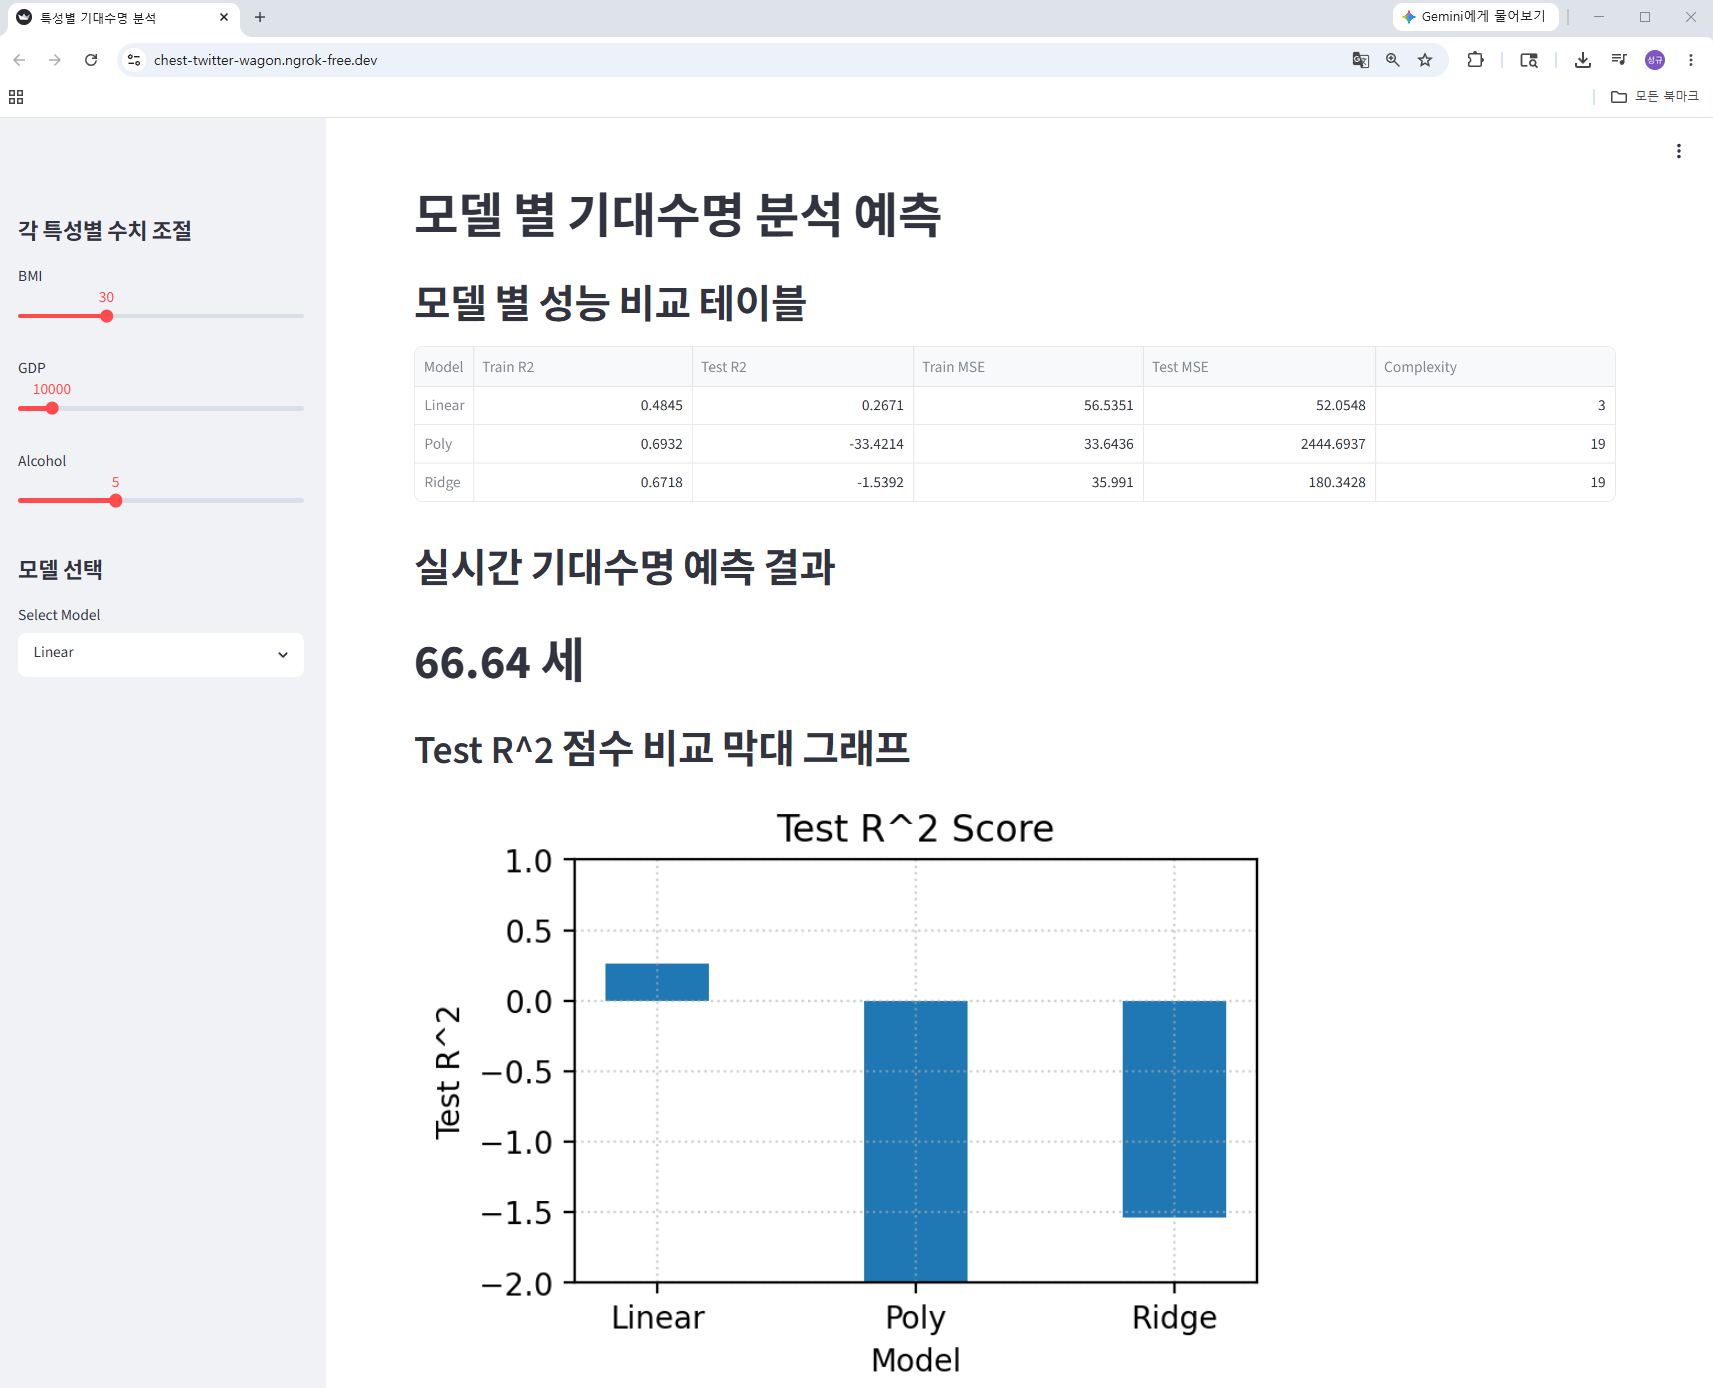

## 모바일 캡쳐
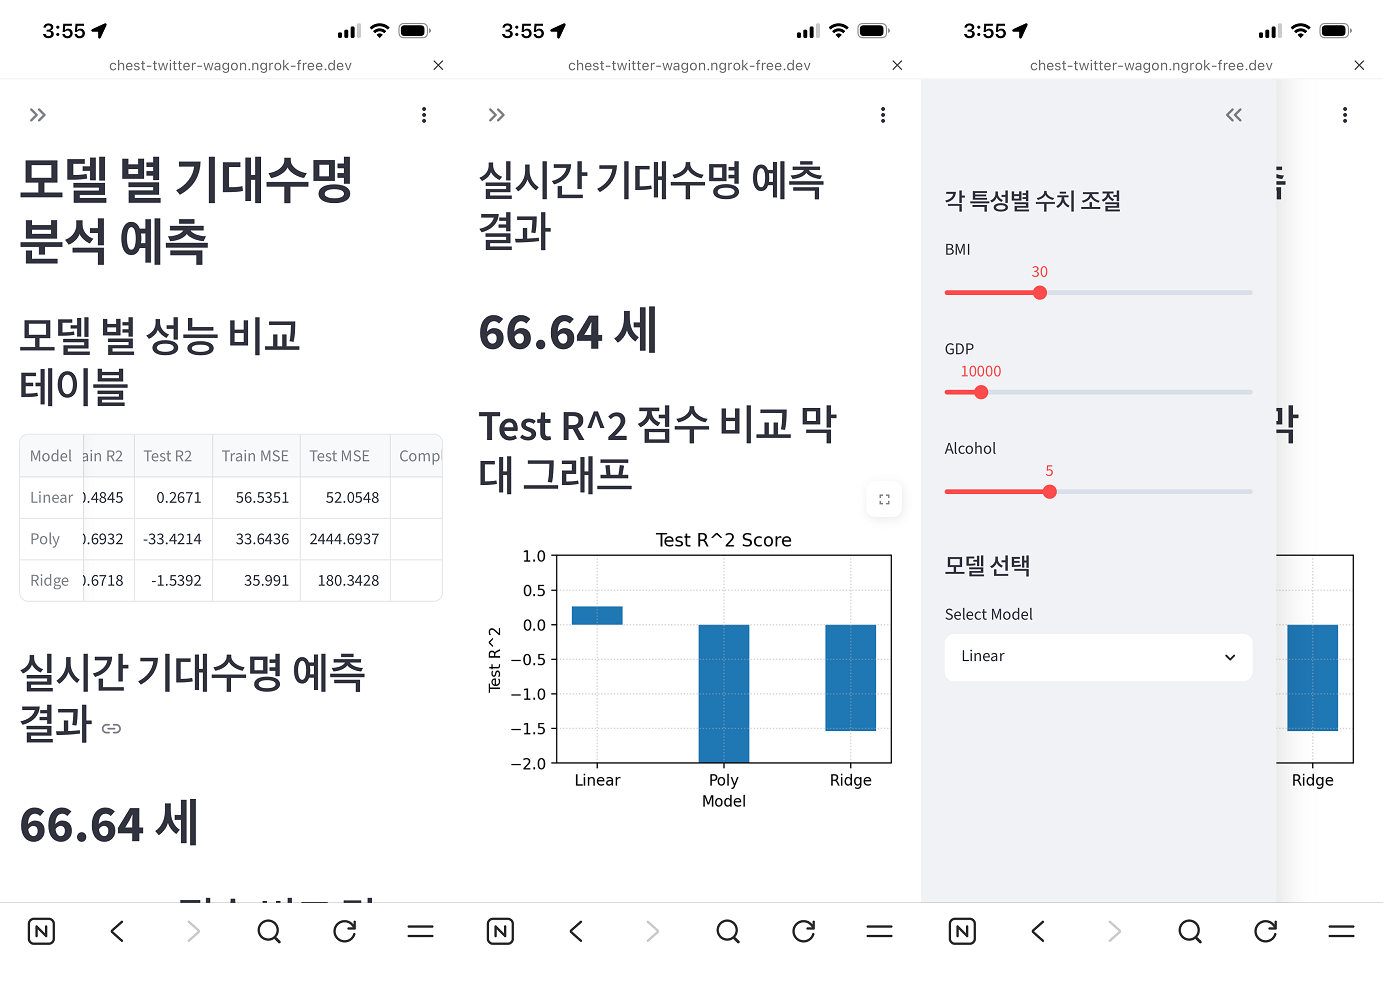

In [1]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.1 MB/s eta 0:00:00


In [2]:
import pandas as pd # 결측치 제거 및 데이터프레임에서 필요한 Features 추출을 위한 라이브러리
import numpy as np # 수치 연산 및 배열 처리를 위한 라이브러리
from sklearn.model_selection import train_test_split # 데이터 분할
from sklearn.linear_model import LinearRegression, Ridge # 선형회귀 모델과 릿지 회귀 모델
from sklearn.preprocessing import PolynomialFeatures, StandardScaler # 다항 특성을 생성하는 기능과 데이터의 특성 스케일을 평균 0, 분산 1로 맞추는 표준화 도구
from sklearn.pipeline import Pipeline # 데이터 전처리와 모델 학습 과정을 하나로 묶어주는 파이프라인
import joblib # 학습된 모델 및 데이터를 파일로 저장/로드

# 지도학습 데이터 준비 (기대수명과 BMI, GDP, Alcohol)
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv" # 데이터 불러오기
df = pd.read_csv(url).dropna() # 결측치 제거

X = df[['BMI', 'GDP', 'Alcohol']].values  # 특성
y = df['Life expectancy'].values  # 타겟

# 과대적합을 의도적으로 발생시키기 위해 훈련 데이터를 단 50개만 추출
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 학습용 80%, 테스트용 20% 데이터 분할
np.random.seed(42) # 시드 고정
sample_indices = np.random.choice(len(X_train_full), 50, replace=False) # 과대적합을 유도하기 위한 50개 데이터 선택
X_train = X_train_full[sample_indices] # 최종 50개의 훈련 데이터
y_train = y_train_full[sample_indices] # 최종 50개의 정답 데이터

# 파이프라인 기반 모델 3종 학습 및 저장
# 1. 선형 회귀 모델
model_linear = Pipeline([
    ('scaler', StandardScaler()), # 표준화
    ('poly', PolynomialFeatures(degree=1, include_bias=False)), # 1차 항으로 두어 기본 선형 회귀
    ('linear', LinearRegression()) # 선형 회귀
])
# 2. 다항 회귀 모델
model_poly = Pipeline([
    ('scaler', StandardScaler()), # 표준화
    ('poly', PolynomialFeatures(degree=3, include_bias=False)), # 3차 항으로 확장.
    ('linear', LinearRegression()) # 다항 데이터로 선형 회귀 모델
])
# 3. 릿지 회귀 모델
model_ridge = Pipeline([
    ('scaler', StandardScaler()), # 표준화
    ('poly', PolynomialFeatures(degree=3, include_bias=False)), # 3차 항으로 확장
    ('ridge', Ridge(alpha=1.0)) # 과대적합을 막기 위한 릿지 규제로 람다값 1.0으로 설정
])

model_linear.fit(X_train, y_train) # 기본 선형 회귀 학습
model_poly.fit(X_train, y_train) # 3차 다항 회귀 학습
model_ridge.fit(X_train, y_train) # 릿지 회귀 모델 학습

joblib.dump(model_linear, 'model_linear.pkl') # 학습이 완료된 기본 선형 회귀 모델 pkl파일로 저장
joblib.dump(model_poly, 'model_poly.pkl') # 학습이 완료된 3차 다항 회귀 모델 pkl파일로 저장
joblib.dump(model_ridge, 'model_ridge.pkl') # 학습이 완료된 릿지 회귀 모델 pkl파일로 저장

print("✅ 모델과 기준값이 파일로 저장되었습니다: model_linear.pkl model_poly.pkl model_ridge.pkl")

✅ 모델과 기준값이 파일로 저장되었습니다: model_linear.pkl model_poly.pkl model_ridge.pkl


In [3]:
%%writefile app.py

import streamlit as st # 웹 대시보드 화면을 구성하는 라이브러리
import numpy as np # 수치 연산 및 배열 처리를 위한 라이브러리
import pandas as pd # 결측치 제거 및 데이터프레임에서 필요한 Features 추출을 위한 라이브러리
import joblib # 학습된 모델 및 데이터를 파일로 저장/로드
import matplotlib.pyplot as plt # 모델 비교 그래프를 그리기 위한 라이브러리
from sklearn.model_selection import train_test_split # 데이터 분할
from sklearn.metrics import mean_squared_error, r2_score # 모델 성능 평가를 위한 MSE와 R2_Score 함수 라이브러리

# 지도학습 데이터 준비 (기대수명과 BMI, GDP, Alcohol)
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv" # 데이터 불러오기
df = pd.read_csv(url).dropna() # 결측치 제거

X = df[['BMI', 'GDP', 'Alcohol']].values  # 특성
y = df['Life expectancy'].values  # 타겟

# 과대적합을 의도적으로 발생시키기 위해 훈련 데이터를 단 50개만 추출
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 학습용 80%, 테스트용 20% 데이터 분할
np.random.seed(42) # 시드 고정
sample_indices = np.random.choice(len(X_train_full), 50, replace=False) # 과대적합을 유도하기 위한 50개 데이터 선택
X_train = X_train_full[sample_indices] # 최종 50개의 훈련 데이터
y_train = y_train_full[sample_indices] # 최종 50개의 정답 데이터

# 저장된 모델 및 기준값 불러오기
model_linear = joblib.load('model_linear.pkl') # 기본 선형 회귀 모델 불러오기
model_poly = joblib.load('model_poly.pkl') # 3차 다항 회귀 모델 불러오기
model_ridge = joblib.load('model_ridge.pkl') # 릿지 회귀 모델 불러오기

# 성능 평가지표 및 총 특성 개수 테이블
# (1) model_linear
train_pred_linear = model_linear.predict(X_train) # 훈련 데이터로 예측값 생성
test_pred_linear = model_linear.predict(X_test) # 테스트 데이터로 예측값 생성

mse_train_linear = mean_squared_error(y_train, train_pred_linear) # 훈련 데이터로 평균제곱오차 계산
mse_test_linear = mean_squared_error(y_test, test_pred_linear) # 테스트 데이터로 평균제곱오차 계산

r2_train_linear = r2_score(y_train, train_pred_linear) # 훈련 데이터로 결정계수 계산
r2_test_linear = r2_score(y_test, test_pred_linear) # 테스트 데이터로 결정계수 계산

# (2) model_poly
train_pred_poly = model_poly.predict(X_train) # 훈련 데이터로 예측값 생성
test_pred_poly = model_poly.predict(X_test) # 테스트 데이터로 예측값 생성

mse_train_poly = mean_squared_error(y_train, train_pred_poly) # 훈련 데이터로 평균제곱오차 계산
mse_test_poly = mean_squared_error(y_test, test_pred_poly) # 테스트 데이터로 평균제곱오차 계산

r2_train_poly = r2_score(y_train, train_pred_poly) # 훈련 데이터로 결정계수 계산
r2_test_poly = r2_score(y_test, test_pred_poly) # 테스트 데이터로 결정계수 계산

# (3) model_ridge
train_pred_ridge = model_ridge.predict(X_train) # 훈련 데이터로 예측값 생성
test_pred_ridge = model_ridge.predict(X_test) # 테스트 데이터로 예측값 생성

mse_train_ridge = mean_squared_error(y_train, train_pred_ridge) # 훈련 데이터로 평균제곱오차 계산
mse_test_ridge = mean_squared_error(y_test, test_pred_ridge) # 테스트 데이터로 평균제곱오차 계산

r2_train_ridge = r2_score(y_train, train_pred_ridge) # 훈련 데이터로 결정계수 계산
r2_test_ridge = r2_score(y_test, test_pred_ridge) # 테스트 데이터로 결정계수 계산

# DataFrame 생성
metrix = {
    'Model': ['Linear', 'Poly', 'Ridge'], # 행 구분을 위한 모델 이름 리스트
    'Train R2': [r2_train_linear, r2_train_poly, r2_train_ridge], # 각 모델의 훈련 R2점수
    'Test R2': [r2_test_linear, r2_test_poly, r2_test_ridge], # 각 모델의 테스트 R2점수
    'Train MSE': [mse_train_linear, mse_train_poly, mse_train_ridge], # 각 모델의 훈련 MSE
    'Test MSE': [mse_test_linear, mse_test_poly, mse_test_ridge], # 각 모델의 테스트 MSE
    'Complexity': [3, 19, 19]  # 총 특성 개수. Linear 3개, Poly와 Ridge 19개
}
df_table = pd.DataFrame(metrix) # 데이터프레임 구조로 변환

# 웹 브라우저의 페이지 제목과 레이아웃(와이드 모드)을 설정
st.set_page_config(page_title="특성별 기대수명 분석", layout="wide")
# 웹 대시보드 최상단에 큰 메인 제목 출력
st.title("모델 별 기대수명 분석 예측")

# 테이블 출력
st.header("모델 별 성능 비교 테이블")
st.dataframe(df_table.set_index('Model')) # Model열을 기준으로 설정하여 성능비교 테이블 출력

# 사이드바 구현
st.sidebar.header("각 특성별 수치 조절")  # 왼쪽 사이드바 영역에 입력용 헤더 텍스트 출력
u_bmi = st.sidebar.slider("BMI", 0, 100, 30) # 최소 0, 최대 100, 기본값 30. BMI 조절 슬라이더
u_gdp = st.sidebar.slider("GDP", 0, 100000, 10000) # 최소 0, 최대 100,000, 기본값 10,000. GDP 조절 슬라이더
u_alc = st.sidebar.slider("Alcohol", 0, 15, 5) # 최소 0, 최대 15, 기본값 5. 알코올 조절 슬라이더

# 모델 선택 인터페이스
st.sidebar.header("모델 선택") # 왼쪽 사이드바 영역에 입력용 모델 선택하는 인터페이스 헤더 텍스트
selected_model = st.sidebar.selectbox("Select Model", ["Linear", "Poly", "Ridge"]) # 모델 선택 드롭다운 리스트 제공

# 실시간 동적 예측 결과 출력
st.header("실시간 기대수명 예측 결과") # 메인 화면 예측 결과 헤더 텍스트
model_map = { # 사용자가 선택한 모델의 이름과 실제 불러온 모델 객체를 각각 셋팅
    'Linear': model_linear, # Linear모델
    'Poly': model_poly, # Poly모델
    'Ridge': model_ridge # Ridge모델
}
target_model = model_map[selected_model] # 사용자가 드롭다운에서 선택한 모델 객체 추출
user_input = np.array([[u_bmi, u_gdp, u_alc]]) # 사용자가 슬라이더로 조절한 3개의 값을 2차원 배열로 추출
prediction = target_model.predict(user_input) # 추출한 모델과 입력값으로 predict
st.write(f"# {prediction[0]:.2f} 세") # 예측된 결과를 출력. 굵게, 크게 표시

# 3종 모델의 Test R^2 점수 비교 막대 그래프
st.header("Test R^2 점수 비교 막대 그래프") # 점수 비교 그래프의 헤더 텍스트
fig, ax = plt.subplots(figsize=(4, 2.5)) # 그래프를 그릴 새로운 도화지와 축을 생성
bars = ax.bar(df_table['Model'], df_table['Test R2'], width=0.4) # x축에는 모델명, y축에는 R2점수를 대입
ax.set_xlabel('Model') # x축 레이블 설정
ax.set_ylabel('Test R^2') # y축 레이블 설정
ax.set_title('Test R^2 Score') # 그래프의 상단 제목 설정
ax.set_ylim((-2, 1)) # 과대적합으로 인한 큰 범위의 y축을 -2와 1사이로 설정
ax.grid(True, linestyle=':', alpha=0.6) # 격자 표시
st.pyplot(fig, use_container_width=False) # 그래프 출력

Writing app.py


In [4]:
# 기존 코드를 멈추고, 아래 코드로 다시 실행.
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3DyfMQcpq3EBGuU2bDQxmpejk84_4pg38yfLvnkcDVWufKMUA")

# 3. Streamlit 실행
os.system("streamlit run app.py --server.address 127.0.0.1 &")

# 4. ngrok 터널 연결
public_url = ngrok.connect(8501, bind_tls=True)
print(f"아래 링크를 클릭하세요:\n{public_url}")


아래 링크를 클릭하세요:
NgrokTunnel: "https://chest-twitter-wagon.ngrok-free.dev" -> "http://localhost:8501"
